In [3]:
# Install kagglehub
!pip install kagglehub -q

# Download the dataset
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")
print("Path to dataset files:", path)

# List files in the downloaded path
files = os.listdir(path)
print("Files:", files)

Using Colab cache for faster access to the 'unlock-profits-with-e-commerce-sales-data' dataset.
Path to dataset files: /kaggle/input/unlock-profits-with-e-commerce-sales-data
Files: ['Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'May-2022.csv', 'P  L March 2021.csv', 'International sale Report.csv', 'Expense IIGF.csv', 'Sale Report.csv']


In [4]:
# Load the main sale report
df = pd.read_csv(os.path.join(path, 'Sale Report.csv'))

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: (9271, 7)

First 5 rows:
   index       SKU Code Design No.  Stock       Category Size Color
0      0    AN201-RED-L      AN201    5.0  AN : LEGGINGS    L   Red
1      1    AN201-RED-M      AN201    5.0  AN : LEGGINGS    M   Red
2      2    AN201-RED-S      AN201    3.0  AN : LEGGINGS    S   Red
3      3   AN201-RED-XL      AN201    6.0  AN : LEGGINGS   XL   Red
4      4  AN201-RED-XXL      AN201    3.0  AN : LEGGINGS  XXL   Red

Column names:
['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size', 'Color']

Data types:
index           int64
SKU Code       object
Design No.     object
Stock         float64
Category       object
Size           object
Color          object
dtype: object


In [5]:
# Amazon Sale Report
df_amazon = pd.read_csv(os.path.join(path, 'Amazon Sale Report.csv'))

print("Shape:", df_amazon.shape)
print("\nFirst 5 rows:")
print(df_amazon.head())
print("\nColumns:")
print(df_amazon.columns.tolist())

Shape: (128975, 24)

First 5 rows:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0

/tmp/ipykernel_7907/3114802859.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_amazon = pd.read_csv(os.path.join(path, 'Amazon Sale Report.csv'))


In [6]:
# Filter only completed orders (not cancelled)
df_orders = df_amazon[df_amazon['Status'] != 'Cancelled'].copy()

# Create customer-level dataframe
customer_df = df_orders.groupby('Order ID').agg({
    'Amount': 'sum',           # Total spend per order
    'Qty': 'sum',              # Total items per order
    'ship-state': 'first',     # State (optional)
}).reset_index()

# Remove any missing values
customer_df = customer_df.dropna(subset=['Amount', 'Qty'])

# Basic stats
print("Customers (orders) after cleaning:", len(customer_df))
print("\nFirst 5 rows:")
print(customer_df.head())
print("\nBasic stats:")
print(customer_df[['Amount', 'Qty']].describe())

Customers (orders) after cleaning: 103193

First 5 rows:
              Order ID  Amount  Qty     ship-state
0  171-0000547-8192359   301.0    1    MAHARASHTRA
1  171-0001409-6228339   422.0    1      TELANGANA
2  171-0003082-5110755   563.0    1  UTTAR PRADESH
3  171-0003738-2052324   379.0    1  UTTAR PRADESH
4  171-0005637-8167567   579.0    1          DELHI

Basic stats:
              Amount            Qty
count  103193.000000  103193.000000
mean      694.556743       1.075577
std       369.758790       0.353122
min         0.000000       1.000000
25%       459.000000       1.000000
50%       635.000000       1.000000
75%       824.000000       1.000000
max      8636.000000      15.000000


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Prepare features (using Amount and Qty)
X = customer_df[['Amount', 'Qty']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with 4 clusters (you can change this)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
print("Cluster sizes:")
print(customer_df['Cluster'].value_counts().sort_index())

# Show cluster centers (in original scale)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster centers (Amount, Qty):")
for i, center in enumerate(centers_original):
    print(f"Cluster {i}: Amount = ${center[0]:.0f}, Qty = {center[1]:.1f}")

Cluster sizes:
Cluster
0     5616
1    60343
2      529
3    36705
Name: count, dtype: int64

Cluster centers (Amount, Qty):
Cluster 0: Amount = $1289, Qty = 2.1
Cluster 1: Amount = $476, Qty = 1.0
Cluster 2: Amount = $2806, Qty = 4.0
Cluster 3: Amount = $933, Qty = 1.0


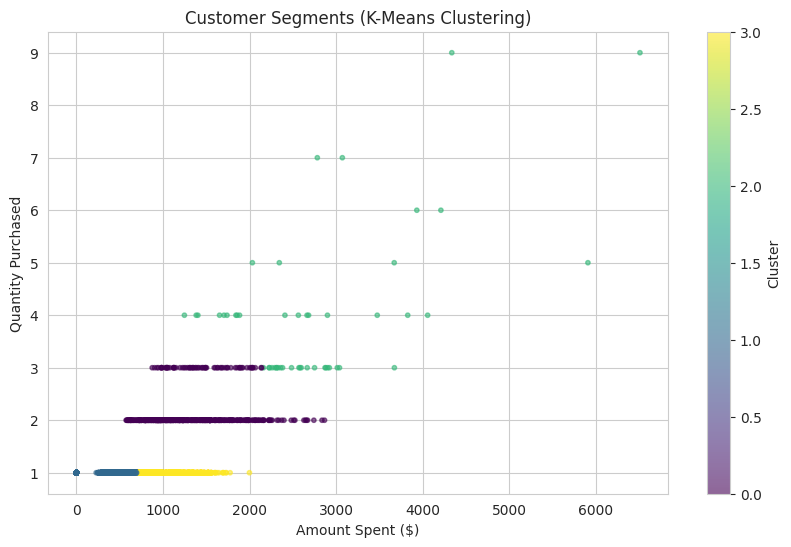

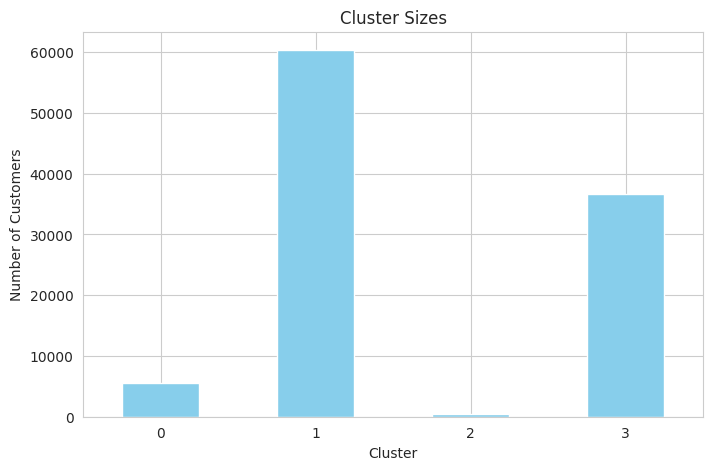

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Scatter plot (sample 10,000 points for speed)
sample_df = customer_df.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample_df['Amount'], sample_df['Qty'],
                      c=sample_df['Cluster'], cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Amount Spent ($)')
plt.ylabel('Quantity Purchased')
plt.title('Customer Segments (K-Means Clustering)')
plt.show()

# Bar plot of cluster sizes
plt.figure(figsize=(8, 5))
customer_df['Cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Sizes')
plt.xticks(rotation=0)
plt.show()

In [9]:
# Install PySpark
!pip install pyspark -q

# Initialize Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("EcommerceClustering").getOrCreate()

# Load data as Spark DataFrame
spark_df = spark.createDataFrame(df_amazon[['Order ID', 'Amount', 'Qty', 'Status']].dropna())

# Show basic Spark operations
print("Spark DataFrame count:", spark_df.count())
print("\nFirst 5 rows:")
spark_df.show(5)

# Aggregation using Spark (simulates MapReduce)
result = spark_df.groupBy("Status").agg(
    {"Amount": "sum", "Qty": "sum"}
).collect()

print("\nAggregation by Status (Total Amount & Qty):")
for row in result:
    print(f"{row['Status']}: Amount={row['sum(Amount)']}, Qty={row['sum(Qty)']}")

# Stop Spark session
spark.stop()

Spark DataFrame count: 121180

First 5 rows:
+-------------------+------+---+--------------------+
|           Order ID|Amount|Qty|              Status|
+-------------------+------+---+--------------------+
|405-8078784-5731545|647.62|  0|           Cancelled|
|171-9198151-1101146| 406.0|  1|Shipped - Deliver...|
|404-0687676-7273146| 329.0|  1|             Shipped|
|403-9615377-8133951|753.33|  0|           Cancelled|
|407-1069790-7240320| 574.0|  1|             Shipped|
+-------------------+------+---+--------------------+
only showing top 5 rows

Aggregation by Status (Total Amount & Qty):
Shipped: Amount=50324255.0, Qty=77851
Shipped - Lost in Transit: Amount=1997.0, Qty=5
Shipped - Delivered to Buyer: Amount=18650815.0, Qty=28886
Shipped - Returning to Seller: Amount=107620.0, Qty=150
Shipped - Rejected by Buyer: Amount=7295.0, Qty=11
Cancelled: Amount=6919284.300000027, Qty=5656
Shipped - Returned to Seller: Amount=1269644.0, Qty=1970
Shipped - Picked Up: Amount=661252.0, Qty=977

In [10]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sample for faster rendering
sample_plotly = customer_df.sample(n=5000, random_state=42)

# Create interactive scatter plot
fig1 = px.scatter(sample_plotly, x='Amount', y='Qty', color='Cluster',
                  title='Customer Segments (Interactive)',
                  labels={'Amount': 'Amount Spent ($)', 'Qty': 'Quantity'},
                  color_continuous_scale='Viridis',
                  opacity=0.6)

# Create cluster summary bar chart
cluster_summary = customer_df.groupby('Cluster').agg({
    'Amount': 'mean',
    'Qty': 'mean'
}).reset_index()

fig2 = px.bar(cluster_summary, x='Cluster', y='Amount',
              title='Average Spend by Cluster',
              labels={'Amount': 'Avg Amount ($)', 'Cluster': 'Segment'},
              color='Cluster', text='Amount')

# Show both
fig1.show()
fig2.show()